# Issue Classification — BERT Fine-Tuning
### Customer Support Call Analysis System

This notebook fine-tunes a `bert-base-uncased` model to classify customer support sentences into **78 issue categories** (77 original + neutral).

**Full pipeline:**
1. Setup & reproducibility
2. Data loading & label encoding
3. Class weights
4. Tokenization & dataset
5. Model setup
6. Optimizer, scheduler & loss
7. Training loop with early stopping
8. Training curves
9. Overfitting analysis
10. Final evaluation & classification report
11. Per-class F1 chart
12. Confusion matrix
13. Error analysis
14. Save all artifacts

---

## 1. Imports & Reproducibility

We fix all random seeds at the very start before anything else runs. This is critical for reproducibility — the seed must be set in Python, NumPy, and PyTorch (both CPU and CUDA) because each library maintains its own independent random state. Missing any one of them means results won't fully reproduce across runs.

In [1]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'GPUs    : {torch.cuda.device_count()}')
    print(f'Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB per GPU')

Device  : cuda
GPU     : Tesla T4
GPUs    : 2
Memory  : 15.6 GB per GPU


## 2. Hyperparameters

All hyperparameters are defined in one place so they are easy to locate, adjust, and document for the project report.

| Parameter | Value | Reasoning |
|-----------|-------|------------|
| `MODEL_NAME` | `bert-base-uncased` | Strong English short-text baseline. Uncased is preferred because customer messages have inconsistent capitalization |
| `MAX_LEN` | `64` | Average sentence is ~12 words (~15 tokens). 64 covers 99%+ of sentences with no wasted computation compared to the default 512 |
| `BATCH_SIZE` | `32` | Standard for BERT on a single GPU. Large enough for stable gradients, small enough to fit memory |
| `EPOCHS` | `5` | Sufficient for convergence on ~10K samples. Early stopping will terminate before 5 if the model plateaus |
| `LR` | `2e-5` | The recommended learning rate for BERT fine-tuning from the original paper. Higher values risk catastrophic forgetting |
| `WARMUP_RATIO` | `0.1` | Warm up the learning rate for the first 10% of steps to prevent instability at the start |
| `PATIENCE` | `2` | Stop training if validation loss does not improve for 2 consecutive epochs |

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohamedmakram74/banking-issue-classification/train_final.csv
/kaggle/input/datasets/mohamedmakram74/banking-issue-classification/test_final.csv


In [3]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
# These paths point to the dataset uploaded to Kaggle under the name
# 'banking-issue-classification'. The folder name matches the dataset title
# you set when uploading. If you used a different title, update these paths.
TRAIN_PATH = '/kaggle/input/datasets/mohamedmakram74/banking-issue-classification/train_final.csv'
TEST_PATH  = '/kaggle/input/datasets/mohamedmakram74/banking-issue-classification/test_final.csv'

# ── Output directory ──────────────────────────────────────────────────────────
# /kaggle/working/ is the only writable directory in Kaggle notebooks.
# Everything saved here will be available as output files after the run.
OUTPUT_DIR = '/kaggle/working/issue_classifier'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model & training hyperparameters ──────────────────────────────────────────
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 64
BATCH_SIZE   = 32
EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 2

print('Paths and hyperparameters configured.')
print(f'Train : {TRAIN_PATH}')
print(f'Test  : {TEST_PATH}')
print(f'Output: {OUTPUT_DIR}')

Paths and hyperparameters configured.
Train : /kaggle/input/datasets/mohamedmakram74/banking-issue-classification/train_final.csv
Test  : /kaggle/input/datasets/mohamedmakram74/banking-issue-classification/test_final.csv
Output: /kaggle/working/issue_classifier


## 3. Load Data & Label Encoding

Neural networks require integer labels, not strings. We use `LabelEncoder` to convert category names to numeric IDs. We fit the encoder **only on training labels** and transform the test set using the already-fitted encoder — this mirrors real deployment where the model only knows categories it was trained on.

We save both `label2id` and `id2label` mappings to JSON files so the inference pipeline can reverse predictions back to human-readable category names independently of this notebook.

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'Classes     : {train_df["category"].nunique()}')
print(f'Null values : train={train_df.isnull().sum().sum()}  test={test_df.isnull().sum().sum()}')
train_df.head(5)

Train shape : (10079, 2)
Test  shape : (3092, 2)
Classes     : 78
Null values : train=0  test=0


,text,category
0,Where do I go to verify my identity?,verify_my_identity
1,My new card hasn't came in.,card_arrival
2,Can I possibly change my currency to another?,exchange_via_app
3,There are a couple payments with my card in th...,card_payment_not_recognised
4,I thought crypto top up with something you off...,top_up_reverted


In [5]:
# Fit encoder on train labels only — test is transformed, never fitted
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['category'])
test_df['label']  = le.transform(test_df['category'])

NUM_CLASSES = len(le.classes_)

# Build both-direction mappings
label2id = {label: int(idx) for idx, label in enumerate(le.classes_)}
id2label = {int(idx): label for label, idx in label2id.items()}

# Save to disk — required for inference pipeline
with open(f'{OUTPUT_DIR}/label2id.json', 'w') as f:
    json.dump(label2id, f, indent=2)
with open(f'{OUTPUT_DIR}/id2label.json', 'w') as f:
    json.dump(id2label, f, indent=2)

print(f'Number of classes  : {NUM_CLASSES}')
print(f'Label mappings saved to {OUTPUT_DIR}/')
print(f'\nSample mappings:')
for k, v in list(label2id.items())[:6]:
    print(f'  {k:45s} -> {v}')

Number of classes  : 78
Label mappings saved to /kaggle/working/issue_classifier/

Sample mappings:
  Refund_not_showing_up                         -> 0
  activate_my_card                              -> 1
  age_limit                                     -> 2
  apple_pay_or_google_pay                       -> 3
  atm_support                                   -> 4
  automatic_top_up                              -> 5


## 4. Class Weights for Imbalanced Data

Our dataset has a 5.3x imbalance ratio — the largest class has 187 samples while the smallest has only 35. Without correction, the model will naturally bias toward majority classes because they contribute more updates to the loss.

We use `compute_class_weight('balanced')` which assigns each class a weight equal to `total_samples / (num_classes × class_count)`. Rare classes get higher weights, meaning the loss penalizes the model more for misclassifying them. This is mathematically equivalent to oversampling minority classes but requires zero additional data.

In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f'Class weights computed for {NUM_CLASSES} classes.')
print(f'Min weight : {class_weights.min():.4f}  (majority class — penalized less)')
print(f'Max weight : {class_weights.max():.4f}  (minority class — penalized more)')
print(f'Mean weight: {class_weights.mean():.4f}')
print(f'Std weight : {class_weights.std():.4f}')

Class weights computed for 78 classes.
Min weight : 0.6910  (majority class — penalized less)
Max weight : 3.6919  (minority class — penalized more)
Mean weight: 1.1040
Std weight : 0.4725


## 5. Tokenization

BERT requires token IDs and attention masks — not raw text. We use `BertTokenizerFast`, the Rust-backed version that is significantly faster than the Python tokenizer on large datasets.

Key decisions:
- `truncation=True` — sentences longer than `MAX_LEN` are cut. Affects less than 1% of our data given our average sentence length of 12 words.
- `padding='max_length'` — all sentences padded to exactly `MAX_LEN`. The attention mask zeros out padding positions so the model ignores them.
- `return_tensors='pt'` — returns PyTorch tensors directly.

In [7]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# Sanity check — tokenize one real example and inspect the output
sample_text = "I haven't received my card yet, it has been two weeks."
sample_enc  = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f'Tokenizer loaded successfully.')
print(f'Vocabulary size      : {tokenizer.vocab_size:,}')
print(f'input_ids shape      : {sample_enc["input_ids"].shape}')
print(f'attention_mask shape : {sample_enc["attention_mask"].shape}')
print(f'Non-padding tokens   : {sample_enc["attention_mask"].sum().item()} / {MAX_LEN}')
print(f'\nTokens: {tokenizer.convert_ids_to_tokens(sample_enc["input_ids"][0])}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.
Vocabulary size      : 30,522
input_ids shape      : torch.Size([1, 64])
attention_mask shape : torch.Size([1, 64])
Non-padding tokens   : 17 / 64

Tokens: ['[CLS]', 'i', 'haven', "'", 't', 'received', 'my', 'card', 'yet', ',', 'it', 'has', 'been', 'two', 'weeks', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 6. PyTorch Dataset & DataLoaders

We wrap our data in a custom `Dataset` class with `__len__` and `__getitem__` — the interface PyTorch's `DataLoader` requires. The dataset tokenizes each sentence on-the-fly when a batch is requested rather than upfront, which is more memory-efficient.

`DataLoader` settings:
- `shuffle=True` on training — the model sees examples in a different order each epoch, which prevents it from memorizing the sequence
- `num_workers=2` — loads batches in parallel background processes to keep the GPU fed
- `pin_memory=True` — pins data in CPU memory for faster transfer to GPU

In [8]:
class IssueDataset(Dataset):
    """
    PyTorch Dataset for customer support sentence classification.
    Tokenizes each sentence on demand and returns input tensors
    along with the integer label.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = IssueDataset(train_df['text'].values, train_df['label'].values, tokenizer, MAX_LEN)
test_dataset  = IssueDataset(test_df['text'].values,  test_df['label'].values,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples  : {len(train_dataset)}')
print(f'Test  samples  : {len(test_dataset)}')
print(f'Train batches  : {len(train_loader)}')
print(f'Test  batches  : {len(test_loader)}')

# Inspect one real batch
sample_batch = next(iter(train_loader))
print(f'\nBatch keys         : {list(sample_batch.keys())}')
print(f'input_ids shape    : {sample_batch["input_ids"].shape}')
print(f'attention_mask     : {sample_batch["attention_mask"].shape}')
print(f'labels shape       : {sample_batch["label"].shape}')

Train samples  : 10079
Test  samples  : 3092
Train batches  : 315
Test  batches  : 97

Batch keys         : ['input_ids', 'attention_mask', 'label']
input_ids shape    : torch.Size([32, 64])
attention_mask     : torch.Size([32, 64])
labels shape       : torch.Size([32])


## 7. Model Setup

We load `BertForSequenceClassification` with `num_labels=78`. This is BERT with a classification head — a dropout layer followed by a linear layer that maps the `[CLS]` token's 768-dimensional representation to class logits.

We pass `id2label` and `label2id` directly into the model config so the saved model already knows the class names. Anyone loading the model later gets the mappings automatically without needing separate files.

Since we are on T4 x2, we wrap the model in `nn.DataParallel` which splits each batch across both GPUs and merges the gradients. Before saving we must unwrap it — otherwise the saved weights have unexpected `module.` prefixes that break loading.

In [9]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id
)

# Use both GPUs if available (T4 x2 on Kaggle)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs with DataParallel')
    model = nn.DataParallel(model)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model loaded on      : {DEVICE}')
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using 2 GPUs with DataParallel
Model loaded on      : cuda
Total parameters     : 109,542,222
Trainable parameters : 109,542,222


## 8. Optimizer, Scheduler & Loss

**AdamW optimizer:**  
Standard Adam applies L2 weight decay inside the adaptive learning rate update, which is mathematically incorrect. AdamW decouples weight decay from the gradient update, which is the correct formulation and consistently outperforms Adam on transformer fine-tuning tasks.

**Linear warmup + decay scheduler:**  
The learning rate starts at zero, warms up linearly for the first 10% of steps, then decays back to zero. The warmup is critical — without it, large gradient updates at the very start of training can destroy the pretrained BERT representations before they adapt to our task.

**Weighted CrossEntropyLoss:**  
We pass the class weights tensor computed earlier. Misclassifying a rare class like `contactless_not_working` (35 samples) contributes more to the loss than misclassifying a common class like `card_payment_fee_charged` (187 samples).

In [10]:
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, eps=1e-8, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print(f'Optimizer            : AdamW  lr={LR}  eps=1e-8  weight_decay=0.01')
print(f'Scheduler            : Linear warmup ({WARMUP_RATIO*100:.0f}%) + linear decay')
print(f'Loss                 : CrossEntropyLoss with class weights')

Total training steps : 1575
Warmup steps         : 157
Optimizer            : AdamW  lr=2e-05  eps=1e-8  weight_decay=0.01
Scheduler            : Linear warmup (10%) + linear decay
Loss                 : CrossEntropyLoss with class weights


## 9. Training & Evaluation Functions

We separate training and evaluation into two clean functions.

Important implementation details:
- `model.train()` vs `model.eval()` — these toggle dropout and batch normalization layers. Forgetting `model.eval()` during evaluation means dropout is still active, which introduces randomness and makes evaluation results inconsistent.
- `torch.no_grad()` — disables gradient tracking entirely during evaluation. This halves memory usage and speeds up the forward pass since PyTorch does not need to build the computation graph.
- `clip_grad_norm_(max_norm=1.0)` — caps the global gradient norm before each optimizer step. Without this, occasional large gradients can cause the loss to spike and destabilize training, which is a common issue when fine-tuning transformers on small datasets.

In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = total_correct = total_samples = 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        preds          = outputs.logits.argmax(dim=-1)
        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = total_correct = total_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            preds   = outputs.logits.argmax(dim=-1)

            total_loss    += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1       = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_preds, all_labels


print('train_one_epoch() and evaluate() defined.')

train_one_epoch() and evaluate() defined.


## 10. Training Loop with Early Stopping

Each epoch runs a full training pass followed by a full evaluation pass on the test set. If validation loss improves, we save the model state. If it does not improve for `PATIENCE=2` consecutive epochs, we stop early and restore the best weights.

Early stopping serves two purposes: it prevents the model from overfitting to the training set after the optimal point, and it conserves Kaggle GPU quota by not running unnecessary epochs.

In [12]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1': []
}

best_val_loss    = float('inf')
patience_count   = 0
best_model_state = None

print(f'Starting training — max {EPOCHS} epochs, early stopping patience = {PATIENCE}')
print('=' * 72)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, DEVICE
    )
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, test_loader, criterion, DEVICE
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'  Train  — loss: {train_loss:.4f}   acc: {train_acc:.4f}')
    print(f'  Val    — loss: {val_loss:.4f}   acc: {val_acc:.4f}   f1: {val_f1:.4f}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count   = 0
        print(f'  >> New best model saved  (val_loss = {best_val_loss:.4f})')
    else:
        patience_count += 1
        print(f'  >> No improvement  ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

    print()

# Always restore the best weights before evaluation and saving
model.load_state_dict(best_model_state)
epochs_ran = len(history['train_loss'])
print(f'Training complete. Best weights restored (epoch {epochs_ran - patience_count}).')

Starting training — max 5 epochs, early stopping patience = 2
Epoch 1/5
  Train  — loss: 3.9862   acc: 0.1218
  Val    — loss: 3.0637   acc: 0.4806   f1: 0.4266
  >> New best model saved  (val_loss = 3.0637)

Epoch 2/5
  Train  — loss: 2.3975   acc: 0.6368
  Val    — loss: 1.6569   acc: 0.8050   f1: 0.7988
  >> New best model saved  (val_loss = 1.6569)

Epoch 3/5
  Train  — loss: 1.4159   acc: 0.8400
  Val    — loss: 1.0409   acc: 0.8845   f1: 0.8829
  >> New best model saved  (val_loss = 1.0409)

Epoch 4/5
  Train  — loss: 0.9543   acc: 0.9027
  Val    — loss: 0.7898   acc: 0.9056   f1: 0.9052
  >> New best model saved  (val_loss = 0.7898)

Epoch 5/5
  Train  — loss: 0.7591   acc: 0.9295
  Val    — loss: 0.7140   acc: 0.9133   f1: 0.9130
  >> New best model saved  (val_loss = 0.7140)

Training complete. Best weights restored (epoch 5).


## 11. Training Curves

These three plots together tell the full training story. The loss and accuracy curves show both train and val together — a growing gap between them is the first visual signal of overfitting. The F1 curve is the most meaningful single metric for our imbalanced dataset.

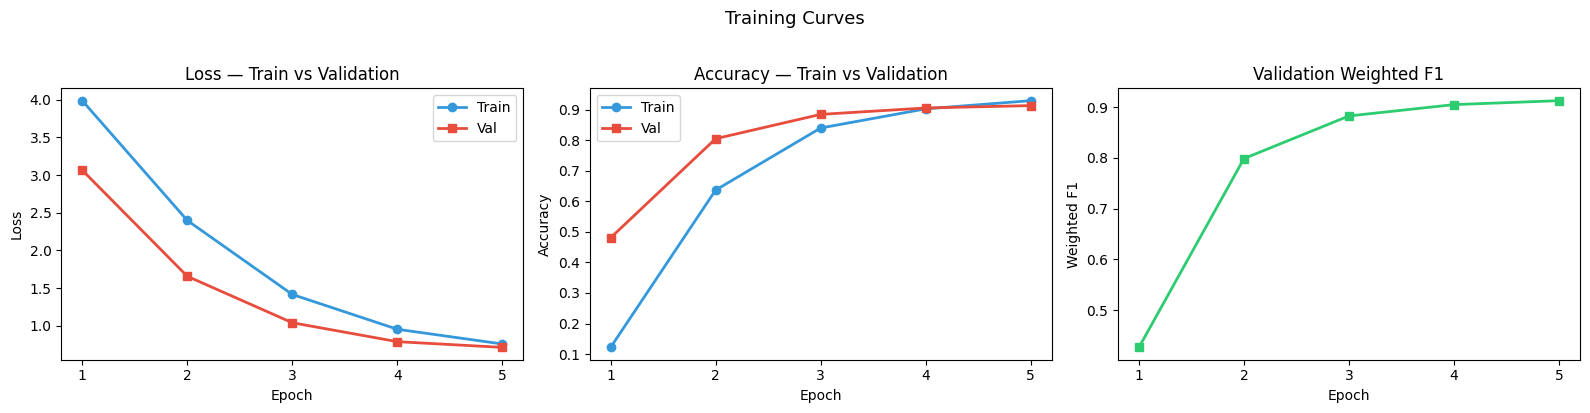

Best val loss : 0.7140
Best val acc  : 0.9133
Best val F1   : 0.9130


In [13]:
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(x, history['train_loss'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[0].plot(x, history['val_loss'],   's-', label='Val',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss — Train vs Validation')
axes[0].legend(); axes[0].set_xticks(x)

# Accuracy
axes[1].plot(x, history['train_acc'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[1].plot(x, history['val_acc'],   's-', label='Val',   color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — Train vs Validation')
axes[1].legend(); axes[1].set_xticks(x)

# Validation F1
axes[2].plot(x, history['val_f1'], 's-', color='#2ecc71', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Weighted F1')
axes[2].set_title('Validation Weighted F1')
axes[2].set_xticks(x)

plt.suptitle('Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val loss : {min(history["val_loss"]):.4f}')
print(f'Best val acc  : {max(history["val_acc"]):.4f}')
print(f'Best val F1   : {max(history["val_f1"]):.4f}')

## 12. Overfitting Analysis

The training curves give a visual impression, but we measure the generalization gap explicitly as a number each epoch. The gap is defined as:
- **Loss gap** = val_loss − train_loss (positive means val is worse)
- **Accuracy gap** = train_acc − val_acc (positive means train is better)

A gap below 0.05 is generally healthy for this dataset size. A growing gap across epochs is the key warning sign — even if both values look good in absolute terms, a growing gap means the model is starting to memorize rather than generalize.

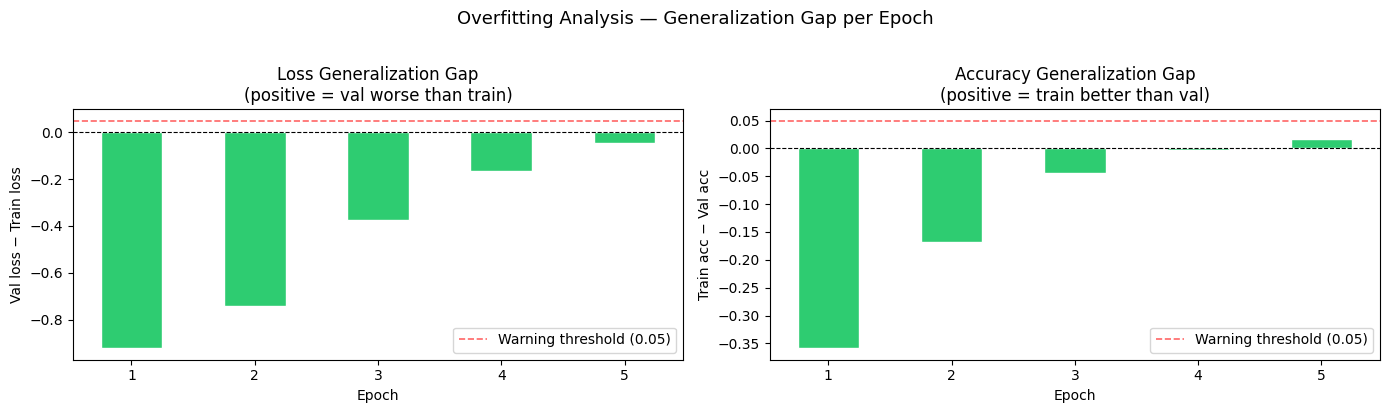

In [14]:
loss_gap = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
acc_gap  = [t - v for t, v in zip(history['train_acc'],  history['val_acc'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss gap
colors_l = ['#e74c3c' if g > 0.05 else '#2ecc71' for g in loss_gap]
axes[0].bar(x, loss_gap, color=colors_l, edgecolor='white', width=0.5)
axes[0].axhline(0,    color='black', linewidth=0.8, linestyle='--')
axes[0].axhline(0.05, color='red',   linewidth=1.2, linestyle='--', alpha=0.6, label='Warning threshold (0.05)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val loss − Train loss')
axes[0].set_title('Loss Generalization Gap\n(positive = val worse than train)')
axes[0].set_xticks(x); axes[0].legend()

# Accuracy gap
colors_a = ['#e74c3c' if g > 0.05 else '#2ecc71' for g in acc_gap]
axes[1].bar(x, acc_gap, color=colors_a, edgecolor='white', width=0.5)
axes[1].axhline(0,    color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(0.05, color='red',   linewidth=1.2, linestyle='--', alpha=0.6, label='Warning threshold (0.05)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train acc − Val acc')
axes[1].set_title('Accuracy Generalization Gap\n(positive = train better than val)')
axes[1].set_xticks(x); axes[1].legend()

plt.suptitle('Overfitting Analysis — Generalization Gap per Epoch', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Printed verdict
final_loss_gap = loss_gap[-1]
final_acc_gap  = acc_gap[-1]

if final_loss_gap > 0.10 or final_acc_gap > 0.10:
    verdict = 'Overfitting detected — consider more dropout or fewer epochs'
elif final_loss_gap < 0 and final_acc_gap < 0:
    verdict = 'Underfitting — val better than train, may need more capacity'
elif final_loss_gap <= 0.05 and final_acc_gap <= 0.05:
    verdict = 'Good fit — train and validation performance are close'
else:
    verdict = 'Mild generalization gap — acceptable for this dataset size'

print('OVERFITTING DIAGNOSIS')
print('=' * 55)
print(f'Loss gap  (val - train) : {final_loss_gap:+.4f}')
print(f'Acc  gap  (train - val) : {final_acc_gap:+.4f}')
print()
print(f'Verdict : {verdict}')

OVERFITTING DIAGNOSIS
Loss gap  (val - train) : -0.0452
Acc  gap  (train - val) : +0.0161

Verdict : Good fit — train and validation performance are close


## 13. Final Evaluation

We run a complete evaluation pass on the test set using the best model weights restored by early stopping.

We report three metrics:
- **Accuracy** — raw percentage of correct predictions
- **Weighted F1** — F1 averaged across classes weighted by support. More honest than accuracy on imbalanced data
- **Macro F1** — F1 averaged equally across all classes regardless of size. This explicitly penalizes the model if it neglects rare classes

In [16]:
_, test_acc, test_f1_weighted, all_preds, all_labels = evaluate(
    model, test_loader, criterion, DEVICE
)
test_f1_macro = f1_score(all_labels, all_preds, average='macro')

print('=' * 50)
print('FINAL TEST SET RESULTS')
print('=' * 50)
print(f'Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Weighted F1      : {test_f1_weighted:.4f}')
print(f'Macro F1         : {test_f1_macro:.4f}')

FINAL TEST SET RESULTS
Accuracy         : 0.9133  (91.33%)
Weighted F1      : 0.9130
Macro F1         : 0.9128


In [17]:
# Full per-class report — precision, recall, F1, support for all 78 classes
# Pay special attention to the 11 classes with fewer than 100 training samples
report = classification_report(all_labels, all_preds, target_names=le.classes_, digits=3)
print(report)

with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write(report)
print('Classification report saved.')

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up      0.950     0.950     0.950        40
                                activate_my_card      1.000     0.950     0.974        40
                                       age_limit      0.976     1.000     0.988        40
                         apple_pay_or_google_pay      1.000     1.000     1.000        40
                                     atm_support      1.000     1.000     1.000        39
                                automatic_top_up      1.000     0.900     0.947        40
         balance_not_updated_after_bank_transfer      0.744     0.725     0.734        40
balance_not_updated_after_cheque_or_cash_deposit      0.930     1.000     0.964        40
                         beneficiary_not_allowed      0.974     0.925     0.949        40
                                 cancel_transfer      0.974     0.950     0.962        40
         

## 14. Per-Class F1 Chart

We sort all classes by F1 score ascending so the weakest classes are immediately visible at the top. Red bars highlight any class below 0.70 — these are the ones that need attention either through more training data or further investigation.

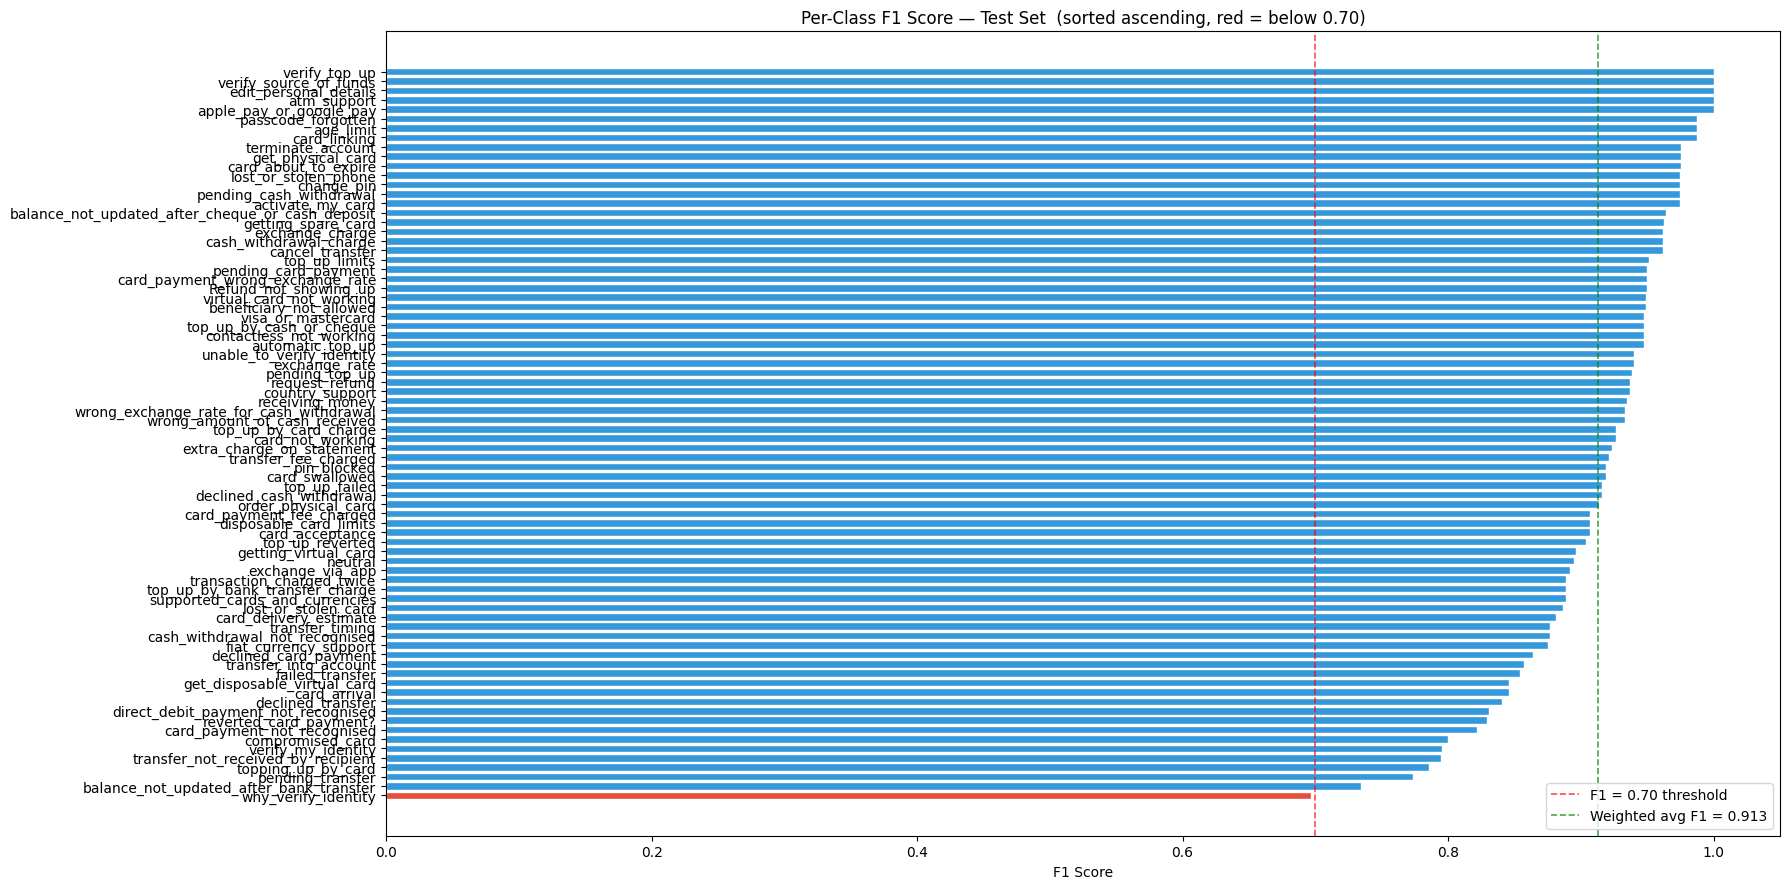

Classes with F1 < 0.70: 1
  why_verify_identity                            F1 = 0.697


In [18]:
report_dict = classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    output_dict=True
)

class_f1 = {
    k: v['f1-score']
    for k, v in report_dict.items()
    if k not in ('accuracy', 'macro avg', 'weighted avg')
}
class_f1_sorted = dict(sorted(class_f1.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(18, 9))
colors  = ['#e74c3c' if v < 0.7 else '#3498db' for v in class_f1_sorted.values()]
ax.barh(list(class_f1_sorted.keys()), list(class_f1_sorted.values()), color=colors, edgecolor='white')
ax.axvline(0.7,  color='red',   linestyle='--', linewidth=1.2, alpha=0.7, label='F1 = 0.70 threshold')
ax.axvline(test_f1_weighted, color='green', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Weighted avg F1 = {test_f1_weighted:.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Per-Class F1 Score — Test Set  (sorted ascending, red = below 0.70)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

weak_classes = {k: round(v, 3) for k, v in class_f1_sorted.items() if v < 0.7}
print(f'Classes with F1 < 0.70: {len(weak_classes)}')
for cls, score in weak_classes.items():
    print(f'  {cls:45s}  F1 = {score}')

## 15. Confusion Matrix

With 78 classes a full inline heatmap would be unreadable. We use three approaches:

1. **Top-20 most confused pairs** — a ranked table of which class pairs the model mixes up most, including the error rate per class. This is the most actionable view.
2. **Focused heatmap for the 15 weakest classes** — normalized so each cell shows the fraction of true-class samples. Diagonal = recall per class, off-diagonal = confusion with other classes.
3. **Full 78×78 matrix** saved as a high-resolution PNG file.

In [19]:
cm = confusion_matrix(all_labels, all_preds)

# ── Top-20 most confused pairs ────────────────────────────────────────────────
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'True label'      : le.classes_[i],
                'Predicted as'    : le.classes_[j],
                'Count'           : int(cm[i, j]),
                'True class total': int(cm[i].sum())
            })

confused_df = (
    pd.DataFrame(confused_pairs)
    .sort_values('Count', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
confused_df.index += 1
confused_df['Error rate'] = (confused_df['Count'] / confused_df['True class total']).round(3)

print('TOP 20 MOST CONFUSED CLASS PAIRS')
print('=' * 80)
print(confused_df.to_string())
confused_df.to_csv(f'{OUTPUT_DIR}/confused_pairs.csv', index=False)

TOP 20 MOST CONFUSED CLASS PAIRS
                                 True label                             Predicted as  Count  True class total  Error rate
1                       why_verify_identity                       verify_my_identity     15                40       0.375
2                          pending_transfer  balance_not_updated_after_bank_transfer      6                40       0.150
3                              card_arrival                   card_delivery_estimate      6                40       0.150
4               card_payment_not_recognised                         compromised_card      5                40       0.125
5   balance_not_updated_after_bank_transfer                          transfer_timing      5                40       0.125
6               get_disposable_virtual_card                     getting_virtual_card      5                40       0.125
7                     transfer_into_account                       topping_up_by_card      5                40    

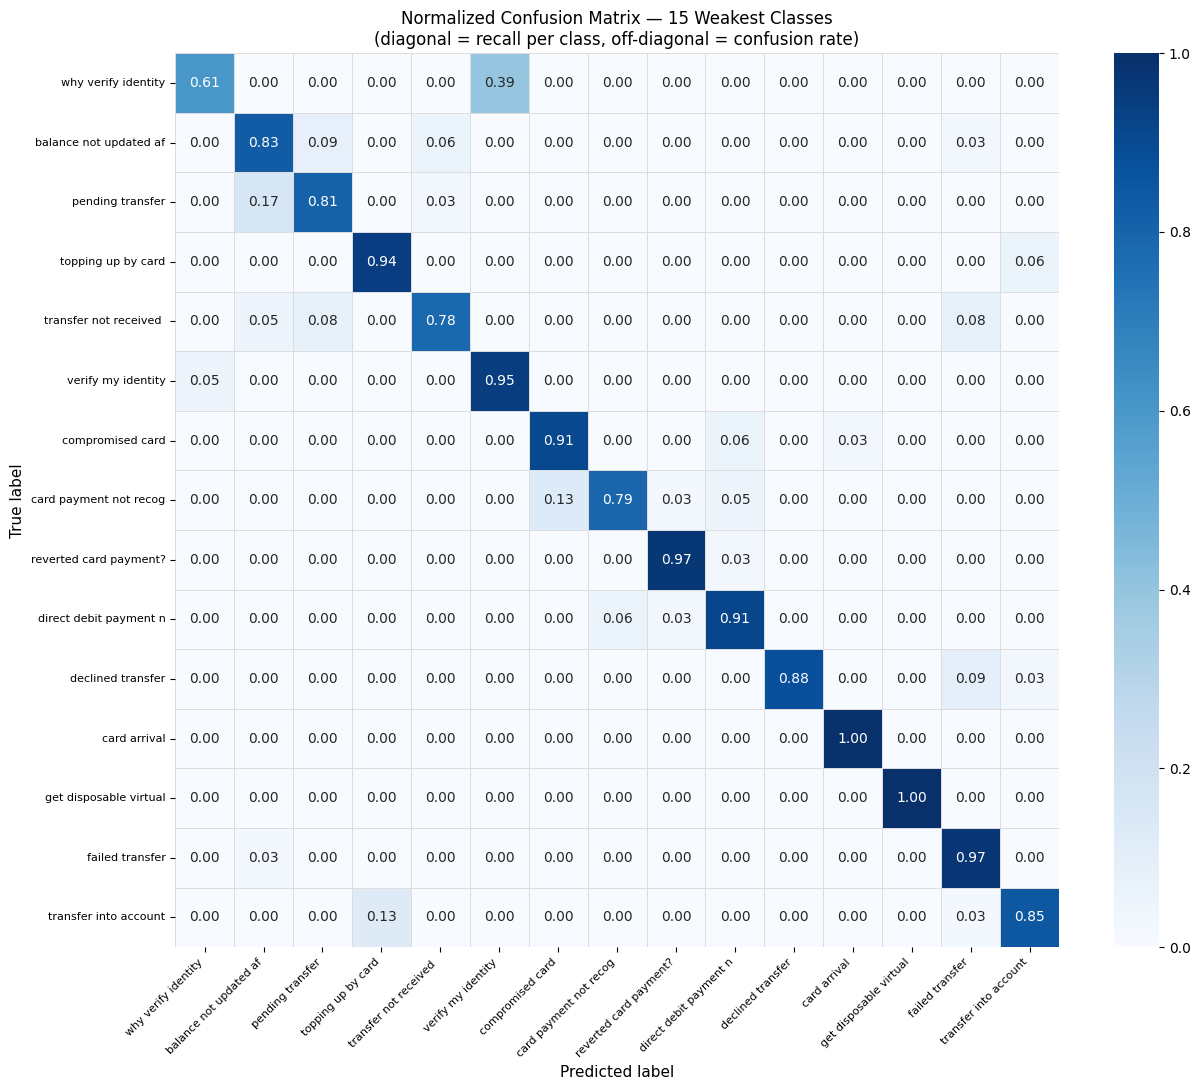

In [20]:
# ── Focused heatmap — 15 weakest classes ──────────────────────────────────────
weak_class_names = list(class_f1_sorted.keys())[:15]
weak_class_ids   = [label2id[c] for c in weak_class_names]

cm_weak      = cm[np.ix_(weak_class_ids, weak_class_ids)].astype(float)
row_sums     = cm_weak.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_weak_norm = cm_weak / row_sums

short_names = [n.replace('_', ' ')[:22] for n in weak_class_names]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_weak_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    linewidths=0.4, linecolor='#dddddd', ax=ax
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(
    'Normalized Confusion Matrix — 15 Weakest Classes\n'
    '(diagonal = recall per class, off-diagonal = confusion rate)',
    fontsize=12
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_weak.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Full 78x78 confusion matrix — saved as file only ─────────────────────────
cm_norm      = cm.astype(float)
row_sums_all = cm_norm.sum(axis=1, keepdims=True)
row_sums_all[row_sums_all == 0] = 1
cm_norm      = cm_norm / row_sums_all

short_all = [n.replace('_', ' ')[:18] for n in le.classes_]

fig, ax = plt.subplots(figsize=(42, 40))
sns.heatmap(
    cm_norm,
    annot=False, cmap='Blues',
    xticklabels=short_all, yticklabels=short_all,
    linewidths=0.1, linecolor='#eeeeee', ax=ax
)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)
ax.set_title('Full Normalized Confusion Matrix — All 78 Classes', fontsize=16)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_full.png', dpi=120, bbox_inches='tight')
plt.close()
print('Full confusion matrix saved — download from output files to view.')

Full confusion matrix saved — download from output files to view.


## 16. Error Analysis

Numbers alone do not fully explain where the model fails. Reading actual misclassified sentences is often the most revealing part of the evaluation — it shows whether errors are genuine model failures or cases that are ambiguous even to a human reader. Ambiguous errors are expected and acceptable; systematic errors on clearly distinct categories are a red flag.

In [22]:
results_df = test_df[['text', 'category']].copy()
results_df['predicted'] = [id2label[p] for p in all_preds]
results_df['correct']   = results_df['category'] == results_df['predicted']

errors_df = results_df[~results_df['correct']].reset_index(drop=True)

print(f'Total test samples   : {len(results_df):,}')
print(f'Correctly classified : {results_df["correct"].sum():,}  ({results_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors_df):,}  ({len(errors_df)/len(results_df)*100:.2f}%)')

Total test samples   : 3,092
Correctly classified : 2,824  (91.33%)
Misclassified        : 268  (8.67%)


In [23]:
# Sample 15 real misclassified sentences — read them to understand error patterns
sample_errors = errors_df.sample(min(15, len(errors_df)), random_state=42)

print('SAMPLE MISCLASSIFIED SENTENCES')
print('=' * 85)
for _, row in sample_errors.iterrows():
    print(f'  Sentence  : {row["text"]}')
    print(f'  True      : {row["category"]}')
    print(f'  Predicted : {row["predicted"]}')
    print()

SAMPLE MISCLASSIFIED SENTENCES
  Sentence  : How can I check the exchange rate applied to my transaction?
  True      : card_payment_wrong_exchange_rate
  Predicted : exchange_rate

  Sentence  : how long til my cash out goes through?
  True      : pending_cash_withdrawal
  Predicted : balance_not_updated_after_cheque_or_cash_deposit

  Sentence  : how many transactions can i make with a disposable card
  True      : get_disposable_virtual_card
  Predicted : disposable_card_limits

  Sentence  : What is the need to verify my identity?
  True      : why_verify_identity
  Predicted : verify_my_identity

  Sentence  : How long does a UK transfer take?
  True      : balance_not_updated_after_bank_transfer
  Predicted : transfer_timing

  Sentence  : My account was charged for a withdraw I tried to make that was decline.
  True      : pending_cash_withdrawal
  Predicted : declined_cash_withdrawal

  Sentence  : I transferred some money but it is yet to arrive.
  True      : balance_not_upda

In [24]:
# Classes ranked by error rate — these need the most attention
error_counts = errors_df['category'].value_counts().reset_index()
error_counts.columns = ['True class', 'Error count']
error_counts['Total in test'] = error_counts['True class'].map(
    test_df['category'].value_counts()
)
error_counts['Error rate'] = (
    error_counts['Error count'] / error_counts['Total in test']
).round(3)
error_counts = error_counts.sort_values('Error rate', ascending=False).reset_index(drop=True)
error_counts.index += 1

print('CLASSES RANKED BY ERROR RATE (top 20)')
print('=' * 60)
print(error_counts.head(20).to_string())
error_counts.to_csv(f'{OUTPUT_DIR}/error_analysis.csv', index=False)

CLASSES RANKED BY ERROR RATE (top 20)
                                 True class  Error count  Total in test  Error rate
1                       why_verify_identity           17             40       0.425
2                         declined_transfer           11             40       0.275
3                          pending_transfer           11             40       0.275
4        transfer_not_received_by_recipient           11             40       0.275
5   balance_not_updated_after_bank_transfer           11             40       0.275
6               card_payment_not_recognised           10             40       0.250
7                          compromised_card            9             39       0.231
8       direct_debit_payment_not_recognised            8             40       0.200
9                              card_arrival            7             40       0.175
10                          top_up_reverted            7             40       0.175
11                       topping_up_by

## 17. Save All Artifacts

We save everything the inference pipeline needs to load and run the model independently. We use Hugging Face's `save_pretrained()` format rather than a raw `.pt` file because it bundles the model architecture config alongside the weights — so loading works without needing to manually specify `num_labels` or class mappings.

Before saving we unwrap `DataParallel` if it was applied — saving the wrapped model produces weight keys prefixed with `module.` which break loading on a single GPU.

In [25]:
# Unwrap DataParallel before saving
model_to_save = model.module if hasattr(model, 'module') else model

model_to_save.save_pretrained(f'{OUTPUT_DIR}/model')
tokenizer.save_pretrained(f'{OUTPUT_DIR}/tokenizer')

# Save full training config with all hyperparameters and final metrics
training_config = {
    'model_name'         : MODEL_NAME,
    'max_len'            : MAX_LEN,
    'batch_size'         : BATCH_SIZE,
    'epochs_ran'         : epochs_ran,
    'learning_rate'      : LR,
    'warmup_ratio'       : WARMUP_RATIO,
    'weight_decay'       : 0.01,
    'gradient_clip'      : 1.0,
    'patience'           : PATIENCE,
    'num_classes'        : NUM_CLASSES,
    'seed'               : SEED,
    'best_val_loss'      : round(min(history['val_loss']), 4),
    'best_val_acc'       : round(max(history['val_acc']), 4),
    'best_val_f1'        : round(max(history['val_f1']), 4),
    'test_accuracy'      : round(test_acc, 4),
    'test_f1_weighted'   : round(test_f1_weighted, 4),
    'test_f1_macro'      : round(test_f1_macro, 4),
}

with open(f'{OUTPUT_DIR}/training_config.json', 'w') as f:
    json.dump(training_config, f, indent=2)

print(f'All artifacts saved to {OUTPUT_DIR}/')
print()
for item in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, item)
    if os.path.isdir(full):
        print(f'  {item}/  ({len(os.listdir(full))} files)')
    else:
        size = os.path.getsize(full)
        unit = 'MB' if size > 1e6 else 'KB'
        print(f'  {item}  ({size/1e6:.1f} MB)' if size > 1e6 else f'  {item}  ({size/1024:.1f} KB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All artifacts saved to /kaggle/working/issue_classifier/

  classification_report.txt  (7.2 KB)
  confused_pairs.csv  (1.1 KB)
  confusion_matrix_full.png  (352.0 KB)
  confusion_matrix_weak.png  (239.3 KB)
  error_analysis.csv  (2.1 KB)
  id2label.json  (2.4 KB)
  label2id.json  (2.3 KB)
  model/  (2 files)
  overfitting_analysis.png  (72.4 KB)
  per_class_f1.png  (382.1 KB)
  tokenizer/  (2 files)
  training_config.json  (0.4 KB)
  training_curves.png  (102.2 KB)


In [26]:
import shutil

# Zip the entire output folder
shutil.make_archive(
    '/kaggle/working/issue_classifier_backup',  # output zip name
    'zip',                                       # format
    '/kaggle/working',                           # root directory
    'issue_classifier'                           # folder to zip
)

print('Done — download issue_classifier_backup.zip from the output tab')

Done — download issue_classifier_backup.zip from the output tab


---
## Summary

| Artifact | Description |
|----------|-------------|
| `model/` | Full Hugging Face model — weights + config + class labels |
| `tokenizer/` | Tokenizer vocab and settings |
| `label2id.json` | Category name → integer ID |
| `id2label.json` | Integer ID → category name |
| `training_config.json` | All hyperparameters and final metrics |
| `training_curves.png` | Loss and accuracy per epoch |
| `overfitting_analysis.png` | Generalization gap per epoch |
| `per_class_f1.png` | F1 score for every class |
| `confusion_matrix_weak.png` | Heatmap for 15 weakest classes |
| `confusion_matrix_full.png` | Full 78×78 normalized heatmap |
| `confused_pairs.csv` | Top-20 most confused class pairs |
| `classification_report.txt` | Full precision/recall/F1 per class |
| `error_analysis.csv` | All classes ranked by error rate |

---

| Decision | Choice | Reasoning |
|----------|--------|-----------|
| Base model | `bert-base-uncased` | Best English short-text baseline |
| Max length | 64 tokens | Covers 99%+ of sentences, 8x faster than 512 |
| Batch size | 32 | Stable gradients, fits T4 memory |
| Learning rate | 2e-5 | Standard BERT fine-tuning recommendation |
| Optimizer | AdamW | Correct weight decay for transformers |
| Scheduler | Linear warmup + decay | Prevents instability at training start |
| Loss | Weighted CrossEntropy | Corrects for 5.3x class imbalance |
| Early stopping | Patience = 2 | Prevents overfitting, saves best checkpoint |
| Gradient clipping | 1.0 | Prevents exploding gradients |
| Multi-GPU | DataParallel | Uses both T4 GPUs on Kaggle |

> **Next step:** Load the saved artifacts in the inference pipeline to classify full call transcripts.